# Coleta e Preparação dos Dados

O PCOS Diagnosis Dataset é um conjunto de dados disponível no Kaggle que contém informações médicas utilizadas para diagnosticar a Síndrome dos Ovários Policísticos (PCOS). Essa síndrome é um distúrbio hormonal comum entre mulheres em idade reprodutiva e pode levar a irregularidades menstruais, dificuldades para engravidar e outros problemas metabólicos.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("samikshadalvi/pcos-diagnosis-dataset")
print("Path to dataset files:", path)

100%|██████████| 6.96k/6.96k [00:00<00:00, 3.08MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/samikshadalvi/pcos-diagnosis-dataset/versions/1


In [ ]:
!ls /root/.cache/kagglehub/datasets/samikshadalvi/pcos-diagnosis-dataset/versions/1

pcos_dataset.csv


# Exporação dos Dados

O conjunto de dados contém diversas variáveis clínicas e hormonais que podem auxiliar na detecção da Síndrome dos Ovários Policísticos (PCOS). Abaixo está a descrição detalhada de cada feature presente no dataset:

* Age (years) – Idade da Paciente: Indica a idade da paciente, variando entre 18 e 45 anos. A idade é um fator relevante, pois a PCOS geralmente afeta mulheres em idade reprodutiva.

* BMI (kg/m²) – Índice de Massa Corporal (IMC): Mede a relação entre peso e altura da paciente. O IMC varia entre 18 e 35, e valores mais altos podem estar associados a resistência à insulina e maior risco de PCOS.

* Menstrual Irregularity (binary) – Irregularidade Menstrual: Indicador binário que mostra se a paciente apresenta ciclos menstruais irregulares (0 = Não, 1 = Sim). Irregularidades menstruais são um dos sintomas mais comuns da PCOS, devido ao desequilíbrio hormonal.

* Testosterone Level (ng/dL) – Nível de Testosterona: Refere-se à quantidade de testosterona no sangue, variando entre 20 e 100 ng/dL. Níveis elevados desse hormônio são uma característica marcante da PCOS e podem causar sintomas como acne e crescimento excessivo de pelos.

* Antral Follicle Count – Contagem de Folículos Antrais: Mede a quantidade de folículos antrais detectados no ultrassom, variando entre 5 e 30. Esse valor é um indicativo da reserva ovariana, e um número maior de folículos pode estar associado à PCOS.

* PCOS Diagnosis (binary) – Diagnóstico de PCOS: Variável binária que indica se a paciente foi diagnosticada com PCOS (0 = Não, 1 = Sim). O diagnóstico é baseado na combinação de fatores de risco, incluindo IMC elevado, níveis de testosterona aumentados, irregularidade menstrual e contagem de folículos antrais.

In [ ]:
import pandas as pd
dataset = pd.read_csv(path + "/pcos_dataset.csv")
dataset.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [ ]:
dataset.tail()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
995,34,18.4,1,95.7,23,0
996,45,28.9,1,28.5,7,0
997,37,28.3,0,32.4,28,0
998,41,27.3,0,95.6,9,0
999,22,21.9,1,78.9,7,0


In [ ]:
dataset.shape

(1000, 6)

In [ ]:
dataset.dtypes

,0
Age,int64
BMI,float64
Menstrual_Irregularity,int64
Testosterone_Level(ng/dL),float64
Antral_Follicle_Count,int64
PCOS_Diagnosis,int64


In [ ]:
dataset.to_csv('pcos_dataset.csv', index=False)

## Idade

In [ ]:
dataset['Age'].value_counts().sort_index()

,count
Age,
18,49
19,33
20,44
21,32
22,43
23,26
24,36
25,33
26,31


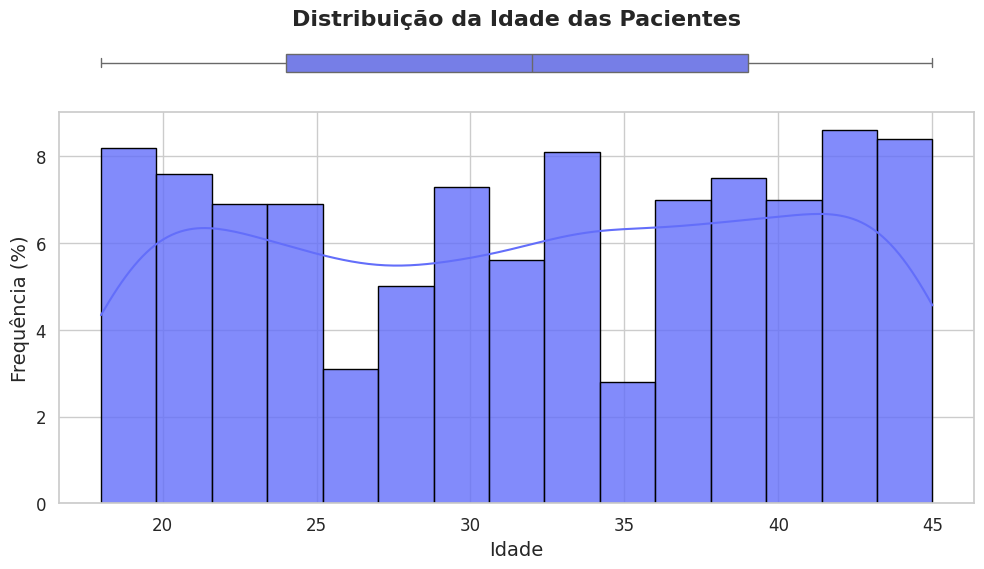

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=dataset,
    x="Age",
    bins=15,
    kde=True,
    stat='percent',
    color="#636EFA",
    edgecolor="black",
    alpha=0.8,
    ax=ax
)

box_ax = ax.inset_axes([0, 1.05, 1, 0.15], sharex=ax)
sns.boxplot(
    data=dataset,
    x="Age",
    ax=box_ax,
    color="#636EFA",
    width=0.3
)
box_ax.axis("off")

ax.set_title("Distribuição da Idade das Pacientes", fontsize=16, fontweight="bold")
ax.set_xlabel("Idade", fontsize=14)
ax.set_ylabel("Frequência (%)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

A distribuição etária das pacientes no conjunto de dados PCOS Diagnosis varia entre 18 e 45 anos, refletindo a fase reprodutiva em que a síndrome pode ser diagnosticada. A distribuição parece relativamente equilibrada entre os 20 e 40 anos, sem grandes variações bruscas. Esse padrão pode ser útil para entender a relação entre a idade e a presença da PCOS, auxiliando na construção de modelos preditivos.

## Contagem de Folículos Antrais

In [ ]:
dataset['Antral_Follicle_Count'].value_counts().sort_index()

,count
Antral_Follicle_Count,
5,34
6,30
7,40
8,35
9,32
10,39
11,32
12,52
13,32


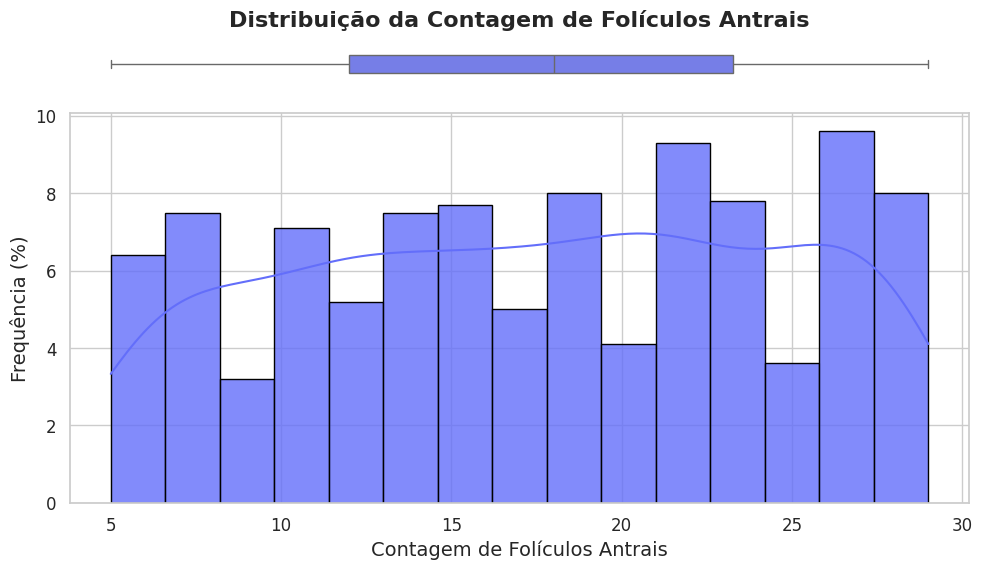

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=dataset,
    x="Antral_Follicle_Count",
    bins=15,
    kde=True,
    stat='percent',
    color="#636EFA",
    edgecolor="black",
    alpha=0.8,
    ax=ax
)

box_ax = ax.inset_axes([0, 1.05, 1, 0.15], sharex=ax)
sns.boxplot(
    data=dataset,
    x="Antral_Follicle_Count",
    ax=box_ax,
    color="#636EFA",
    width=0.3
)
box_ax.axis("off")

ax.set_title("Distribuição da Contagem de Folículos Antrais", fontsize=16, fontweight="bold")
ax.set_xlabel("Contagem de Folículos Antrais", fontsize=14)
ax.set_ylabel("Frequência (%)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

A distribuição da contagem de folículos antrais varia entre 5 e 29, com valores relativamente bem distribuídos ao longo dessa faixa. O maior número de registros está próximo de 12, 17, 21 e 26 folículos, indicando que essa característica pode apresentar variação significativa entre as pacientes. Como a contagem de folículos antrais é um fator importante no diagnóstico da PCOS, valores elevados podem estar associados a um maior risco da síndrome. A análise mais aprofundada pode ajudar a identificar possíveis padrões entre a contagem de folículos e o diagnóstico da PCOS, auxiliando na criação de um modelo preditivo mais preciso.

## Índice de Massa Corporal (BMI)

In [ ]:
dataset['BMI'].value_counts().sort_index()

,count
BMI,
18.1,5
18.2,5
18.3,6
18.4,8
18.5,9
...,...
34.6,3
34.7,7
34.8,8


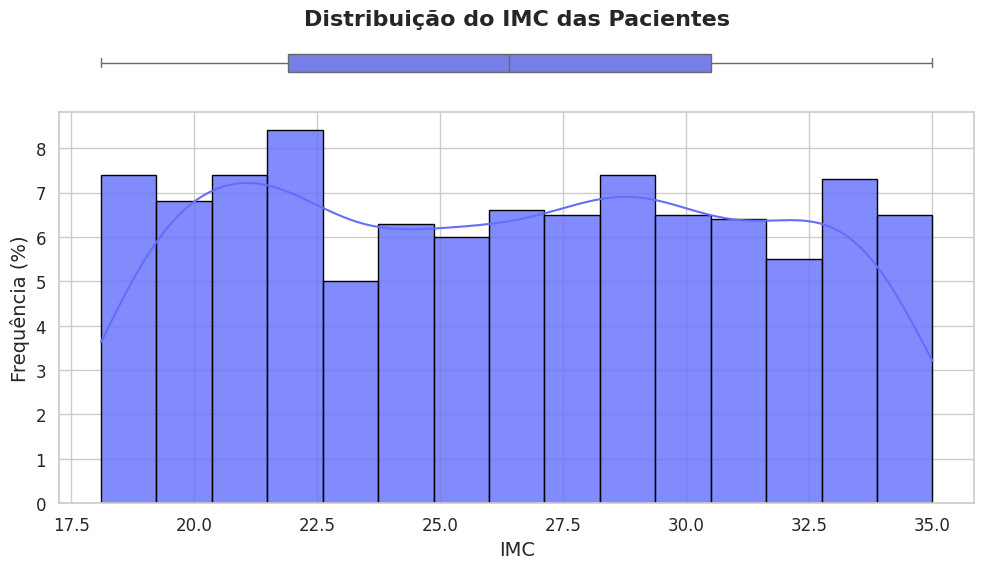

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=dataset,
    x="BMI",
    bins=15,
    kde=True,
    stat='percent',
    color="#636EFA",
    edgecolor="black",
    alpha=0.8,
    ax=ax
)

box_ax = ax.inset_axes([0, 1.05, 1, 0.15], sharex=ax)
sns.boxplot(
    data=dataset,
    x="BMI",
    ax=box_ax,
    color="#636EFA",
    width=0.3
)
box_ax.axis("off")

ax.set_title("Distribuição do IMC das Pacientes", fontsize=16, fontweight="bold")
ax.set_xlabel("IMC", fontsize=14)
ax.set_ylabel("Frequência (%)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

A análise do Índice de Massa Corporal (BMI) no conjunto de dados revela uma média de 26,39 kg/m², o que indica que muitas pacientes estão na faixa de sobrepeso. Os valores variam entre 18,1 kg/m² (próximo ao limite inferior do peso saudável) e 35,0 kg/m² (indicando obesidade). O percentil 25% mostra que um quarto das pacientes tem BMI abaixo de 21,9, enquanto o percentil 75% indica que um quarto tem BMI acima de 30,5, o que reforça a presença de indivíduos com obesidade na amostra. Como o BMI elevado é um fator de risco associado à PCOS, essa variação pode ser relevante para a análise e o desenvolvimento de modelos preditivos para o diagnóstico da síndrome.

## Irregularidade Menstrual

In [ ]:
dataset['Menstrual_Irregularity'].value_counts()

,count
Menstrual_Irregularity,
1,530
0,470


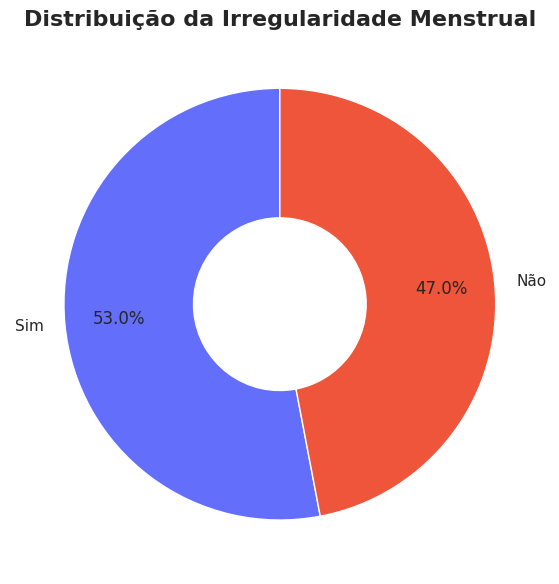

In [ ]:
grouped_data = dataset['Menstrual_Irregularity'].value_counts().reset_index()
grouped_data.columns = ['Menstrual_Irregularity', 'Count']

labels_map = {0: 'Não', 1: 'Sim'}
grouped_data['Menstrual_Irregularity'] = grouped_data['Menstrual_Irregularity'].map(labels_map)

colors = ['#636EFA', '#EF553B']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    grouped_data['Count'],
    labels=grouped_data['Menstrual_Irregularity'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.6}
)

ax.set_title('Distribuição da Irregularidade Menstrual', fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

A análise da irregularidade menstrual no conjunto de dados revela que 530 pacientes (53%) apresentam ciclos menstruais irregulares, enquanto 470 pacientes (47%) possuem ciclos regulares. Esse equilíbrio sugere que a amostra contém uma proporção significativa de mulheres com alterações no ciclo menstrual, um dos principais sintomas da Síndrome dos Ovários Policísticos (PCOS). Como a irregularidade menstrual está frequentemente associada a desequilíbrios hormonais, essa variável pode ser um fator relevante na previsão da PCOS e deve ser analisada em conjunto com outras características, como níveis de testosterona e contagem de folículos antrais, para um diagnóstico mais preciso.

## Nível de Testorsterona

In [ ]:
dataset['Testosterone_Level(ng/dL)'].value_counts().sort_index()

,count
Testosterone_Level(ng/dL),
20.0,2
20.1,3
20.3,2
20.4,1
20.6,2
...,...
99.3,1
99.4,1
99.5,2


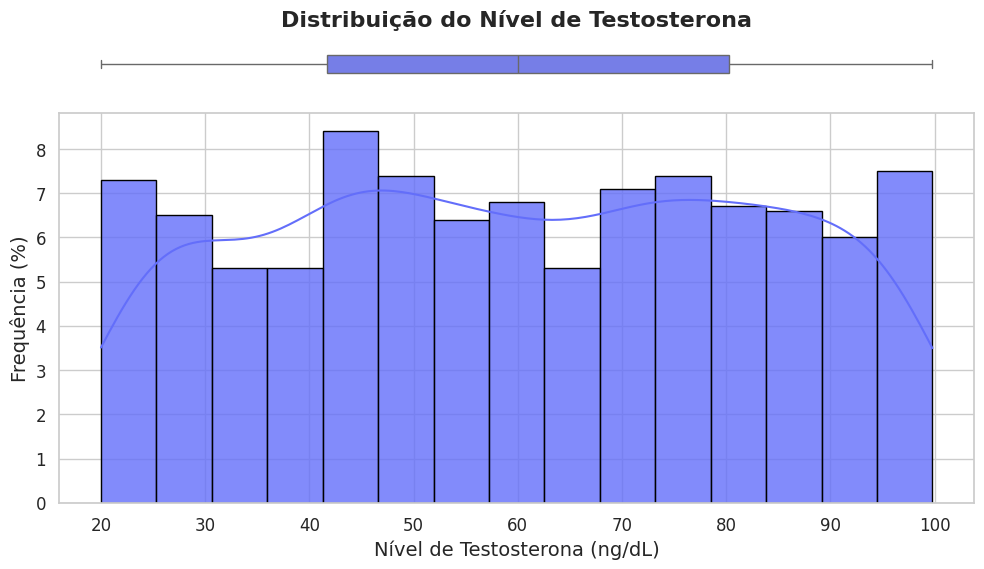

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=dataset,
    x="Testosterone_Level(ng/dL)",
    bins=15,
    kde=True,
    stat='percent',
    color="#636EFA",
    edgecolor="black",
    alpha=0.8,
    ax=ax
)

box_ax = ax.inset_axes([0, 1.05, 1, 0.15], sharex=ax)
sns.boxplot(
    data=dataset,
    x="Testosterone_Level(ng/dL)",
    ax=box_ax,
    color="#636EFA",
    width=0.3
)
box_ax.axis("off")

ax.set_title("Distribuição do Nível de Testosterona", fontsize=16, fontweight="bold")
ax.set_xlabel("Nível de Testosterona (ng/dL)", fontsize=14)
ax.set_ylabel("Frequência (%)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

A análise dos níveis de testosterona no conjunto de dados mostra que os valores variam entre 20,0 ng/dL e 99,8 ng/dL, com uma média de 60,16 ng/dL e um desvio padrão de 23,16 ng/dL. O percentil 25% indica que um quarto das pacientes apresenta níveis abaixo de 41,7 ng/dL, enquanto o percentil 75% mostra que um quarto tem valores acima de 80,3 ng/dL, sugerindo uma distribuição relativamente ampla. Como a testosterona elevada é um dos principais marcadores hormonais da Síndrome dos Ovários Policísticos (PCOS), essa variação pode ter impacto significativo na modelagem preditiva, auxiliando na diferenciação entre pacientes com e sem a condição.

## Diagnóstico de PCOS

In [ ]:
dataset['PCOS_Diagnosis'].value_counts()

,count
PCOS_Diagnosis,
0,801
1,199


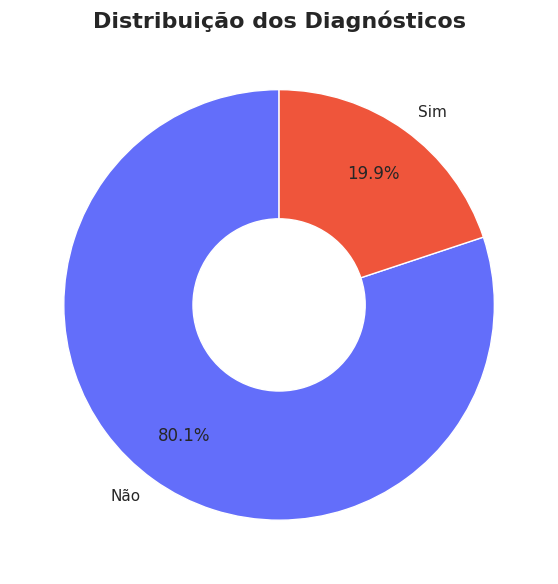

In [ ]:
grouped_data = dataset['PCOS_Diagnosis'].value_counts().reset_index()
grouped_data.columns = ['PCOS_Diagnosis', 'Count']

labels_map = {0: 'Não', 1: 'Sim'}
grouped_data['PCOS_Diagnosis'] = grouped_data['PCOS_Diagnosis'].map(labels_map)

colors = ['#636EFA', '#EF553B']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    grouped_data['Count'],
    labels=grouped_data['PCOS_Diagnosis'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.6}
)

ax.set_title('Distribuição dos Diagnósticos', fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

A análise da variável PCOS Diagnosis mostra que 199 pacientes (19,9%) foram diagnosticadas com Síndrome dos Ovários Policísticos (PCOS), enquanto 801 pacientes (80,1%) não apresentam a condição. Essa distribuição indica que o conjunto de dados está desbalanceado, com uma proporção significativamente maior de indivíduos sem PCOS. Esse desbalanceamento pode impactar o desempenho de modelos preditivos, tornando-os mais propensos a classificar erroneamente casos positivos como negativos. Para mitigar esse efeito, técnicas como reamostragem dos dados (oversampling ou undersampling), uso de métricas adequadas (F1-score, recall, precisão) e ajuste de pesos no modelo podem ser aplicadas para melhorar a capacidade do modelo de identificar corretamente pacientes com PCOS.

# Pré-processamento dos Dados

In [ ]:
dataset.isna().sum()

,0
Age,0
BMI,0
Menstrual_Irregularity,0
Testosterone_Level(ng/dL),0
Antral_Follicle_Count,0
PCOS_Diagnosis,0


In [ ]:
dataset.describe()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.771000,26.38700,0.530000,60.159500,17.469000,0.199000
std,8.463462,4.93554,0.499349,23.160204,7.069301,0.399448
min,18.000000,18.10000,0.000000,20.000000,5.000000,0.000000
25%,24.000000,21.90000,0.000000,41.700000,12.000000,0.000000
50%,32.000000,26.40000,1.000000,60.000000,18.000000,0.000000
75%,39.000000,30.50000,1.000000,80.300000,23.250000,0.000000
max,45.000000,35.00000,1.000000,99.800000,29.000000,1.000000


In [ ]:
dataset.corr()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
Age,1.000000,-0.049455,0.032300,-0.050129,0.017841,-0.064675
BMI,-0.049455,1.000000,0.031189,0.003811,0.030724,0.377852
Menstrual_Irregularity,0.032300,0.031189,1.000000,0.042694,0.035851,0.469376
Testosterone_Level(ng/dL),-0.050129,0.003811,0.042694,1.000000,0.011976,0.200817
Antral_Follicle_Count,0.017841,0.030724,0.035851,0.011976,1.000000,0.192014
PCOS_Diagnosis,-0.064675,0.377852,0.469376,0.200817,0.192014,1.000000


O diagnóstico de PCOS está mais fortemente associado à irregularidade menstrual, seguida por IMC elevado, níveis de testosterona e contagem de folículos antrais. Essas variáveis devem ser consideradas como principais preditores no treinamento de um modelo de Machine Learning.

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   BMI                        1000 non-null   float64
 2   Menstrual_Irregularity     1000 non-null   int64  
 3   Testosterone_Level(ng/dL)  1000 non-null   float64
 4   Antral_Follicle_Count      1000 non-null   int64  
 5   PCOS_Diagnosis             1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


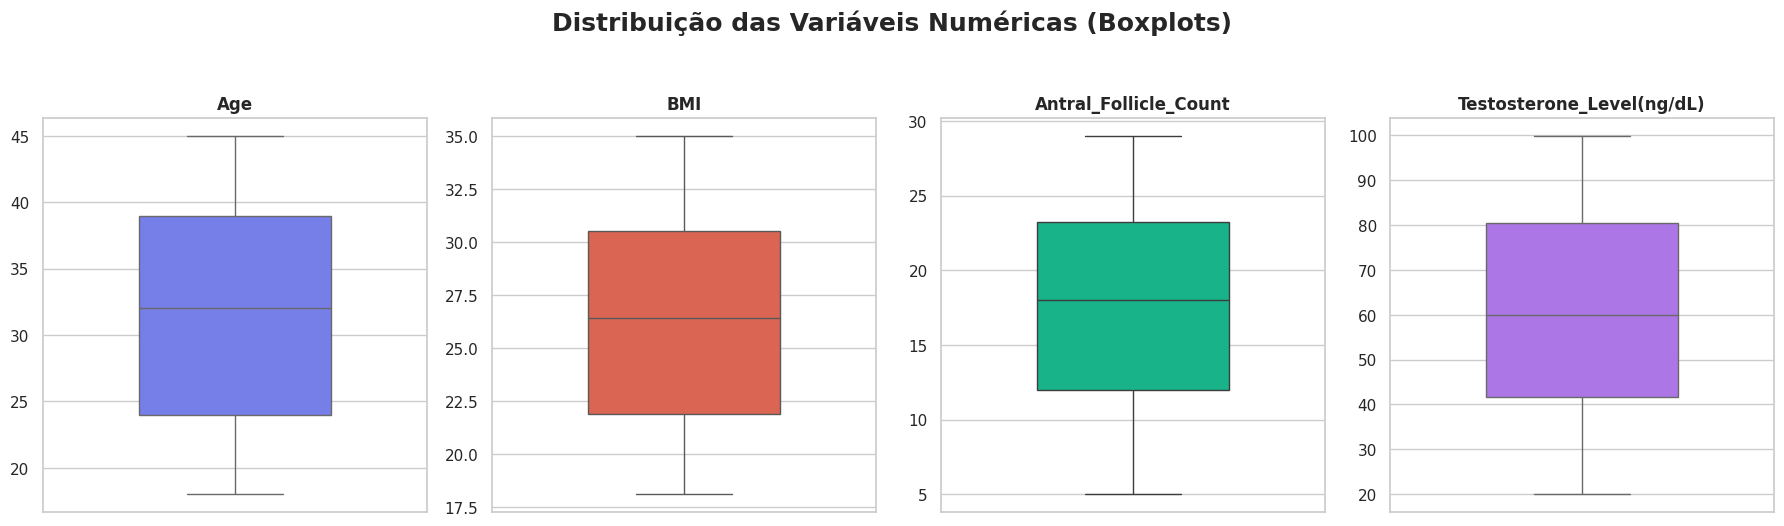

In [ ]:
sns.set_theme(style="whitegrid")

num_cols = ['Age', 'BMI', 'Antral_Follicle_Count', 'Testosterone_Level(ng/dL)']
colors = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5), sharey=False)

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=dataset,
        y=col,
        ax=axes[i],
        color=colors[i],
        width=0.5,
        fliersize=3
    )
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

fig.suptitle("Distribuição das Variáveis Numéricas (Boxplots)", fontsize=18, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

dataset_norm = dataset.copy()

scaler = MinMaxScaler()
dataset_norm[num_cols] = scaler.fit_transform(dataset[num_cols])
dataset_norm.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,0.222222,0.982249,1,0.065163,0.625000,0
1,0.703704,0.491124,0,0.464912,0.833333,0
2,0.518519,0.325444,0,0.911028,0.958333,0
3,0.370370,0.633136,0,0.540100,0.875000,0
4,0.259259,0.236686,1,0.498747,0.125000,0


In [ ]:
dataset.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [ ]:
from sklearn.model_selection import train_test_split

X = dataset_norm.drop('PCOS_Diagnosis', axis=1)
y = dataset_norm['PCOS_Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
print(f"Tamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")

Tamanho do conjunto de treino: (700, 5)
Tamanho do conjunto de teste: (300, 5)


# Treinamento dos Modelos

No processo de detecção e classificação de **Síndrome dos Ovários Policísticos (PCOS)**, é comum testar diversos algoritmos de machine learning para identificar qual apresenta a melhor performance.

Nesta etapa, vamos experimentar diferentes modelos de classificação no dataset de PCOS, utilizando a biblioteca **scikit-learn**, incluindo:

- **GaussianNB** (Naive Bayes Gaussiano)
- **SVC** (Máquina de Vetores de Suporte)
- **KNeighborsClassifier** (K-Nearest Neighbors)
- **DecisionTreeClassifier** (Árvore de Decisão)
- **LogisticRegression** (Regressão Logística)
- **RandomForestClassifier** (Floresta Aleatória)
- **GradientBoostingClassifier** (Boosting de Gradiente)

O objetivo foi comparar algoritmos, garantindo uma visão ampla sobre a capacidade preditiva dos dados disponíveis.


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
model_naive = GaussianNB()
model_naive.fit(X_train, y_train)
predict_naive = model_naive.predict(X_test)

In [ ]:
model_svm = SVC(kernel='linear', random_state=37, C=2)
model_svm.fit(X_train, y_train)
predict_svm = model_svm.predict(X_test)

In [ ]:
model_reg_log = LogisticRegression(penalty='l2', random_state=37, solver='lbfgs', C=2, max_iter=200, tol=0.0001)
model_reg_log.fit(X_train, y_train)
predict_reg_log = model_reg_log.predict(X_test)

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=3, p=1, metric='minkowski')
model_knn.fit(X_train, y_train)
predict_knn = model_knn.predict(X_test)

In [ ]:
model_tree = DecisionTreeClassifier(criterion='entropy', random_state=37, max_depth=4)
model_tree.fit(X_train, y_train)
predict_tree = model_tree.predict(X_test)

In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=37, max_depth=4)
model_rf.fit(X_train, y_train)
predict_rf = model_rf.predict(X_test)

In [ ]:
model_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=37)
model_gb.fit(X_train, y_train)
predict_gb = model_gb.predict(X_test)

# Avaliação dos Modelos

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

predict_models = {
    'Naive Bayes': predict_naive,
    'SVM': predict_svm,
    'Regressão Logística': predict_reg_log,
    'KNN': predict_knn,
    'Árvore de Decisão': predict_tree,
    'Random Forest': predict_rf,
    'Gradient Boosting': predict_gb
}

for name, preds in predict_models.items():
    print("="*60)
    print(f'Classificador: {name}\n')
    print(f'\nAcurácia: {accuracy_score(y_test, preds):.4f}\n')
    print(classification_report(y_test, preds, digits=5))

print("="*60)

Classificador: Naive Bayes


Acurácia: 0.6700

              precision    recall  f1-score   support

           0    1.00000   0.59919   0.74937       247
           1    0.34868   1.00000   0.51707        53

    accuracy                        0.67000       300
   macro avg    0.67434   0.79960   0.63322       300
weighted avg    0.88493   0.67000   0.70833       300

Classificador: SVM


Acurácia: 0.9033

              precision    recall  f1-score   support

           0    0.93600   0.94737   0.94165       247
           1    0.74000   0.69811   0.71845        53

    accuracy                        0.90333       300
   macro avg    0.83800   0.82274   0.83005       300
weighted avg    0.90137   0.90333   0.90222       300

Classificador: Regressão Logística


Acurácia: 0.9100

              precision    recall  f1-score   support

           0    0.93307   0.95951   0.94611       247
           1    0.78261   0.67925   0.72727        53

    accuracy                        0.910

## Análise Preliminar dos Resultados dos Classificadores

### 1. **Naive Bayes**

O modelo **Naive Bayes** apresentou um desempenho modesto, com uma **acurácia de 67%**. Observa-se que ele possui um **recall de 1.0 para a classe minoritária (classe 1)**, mas às custas de uma **baixa precisão (0.34)** para esta classe. Esse comportamento indica que o Naive Bayes está fortemente enviesado para prever a classe 1 em detrimento da classe 0, resultando em muitos **falsos positivos** para a classe majoritária.

---

### 2. **SVM**

O **SVM** alcançou **90.3% de acurácia**, com um equilíbrio razoável entre precisão e recall para ambas as classes. A classe minoritária (classe 1) apresentou **0.74 de precisão** e **0.69 de recall**, o que é aceitável, mas ainda com margem para melhorias.

---

### 3. **Regressão Logística**

A **Regressão Logística** apresentou resultados similares ao SVM, com **91% de acurácia**. Destaca-se uma **melhor precisão (0.78)** para a classe 1 em comparação ao SVM, embora o recall da classe 1 tenha caído para **0.67**. Isso sugere que o modelo é ligeiramente mais conservador para detectar a classe minoritária.

---

### 4. **KNN**

O **KNN** obteve uma acurácia elevada de **96.3%**. A classe 1 foi bem identificada, com **precision de 0.86** e **recall de 0.94**, indicando um ótimo balanceamento entre detectar corretamente os casos positivos (classe 1) e evitar falsos positivos.

---

### 5. **Árvore de Decisão**

O modelo de **Árvore de Decisão** apresentou um desempenho **quase perfeito**, com **99.6% de acurácia**. Ambas as classes tiveram precisão e recall superiores a **0.99**, o que sugere um possível **overfitting** ao conjunto de treinamento, dado o alto desempenho em dados de teste.

---

### 6. **Random Forest**

A **Random Forest** também apresentou **altíssima performance** com **99.3% de acurácia**. O modelo teve uma leve queda no recall da classe 1 (**0.96**), mas manteve precisão em **1.0**. Ainda assim, é um resultado excelente e robusto.

---

### 7. **Gradient Boosting**

O **Gradient Boosting** obteve **100% de acurácia**, precisão e recall para ambas as classes. Isso indica que o modelo classificou **corretamente todas as instâncias** no conjunto de teste. Apesar de impressionante, é necessário investigar se há **overfitting** e testar em outros conjuntos de dados para confirmar a robustez.


# Ajuste e Otimização do Modelo

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 14.5 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

def objective_svm(trial):
    C = trial.suggest_float('C', 0.01, 10, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly'])
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

    model_svm = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        random_state=37
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model_svm, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    return score.mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=30)

print("Melhores parâmetros SVM:", study_svm.best_params)
print(f"Acurácia média em CV: {study_svm.best_value:.4f}")


[I 2025-04-25 19:48:28,258] A new study created in memory with name: no-name-c3bc9207-15b8-4d37-aad5-25d09890e269
[I 2025-04-25 19:48:33,974] Trial 0 finished with value: 0.9042857142857142 and parameters: {'C': 0.43382472034041036, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 0 with value: 0.9042857142857142.
[I 2025-04-25 19:48:34,132] Trial 1 finished with value: 0.9471428571428572 and parameters: {'C': 0.12621915706591014, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 1 with value: 0.9471428571428572.
[I 2025-04-25 19:48:34,245] Trial 2 finished with value: 0.9642857142857142 and parameters: {'C': 0.25644904057322937, 'kernel': 'poly', 'gamma': 'scale'}. Best is trial 2 with value: 0.9642857142857142.
[I 2025-04-25 19:48:34,336] Trial 3 finished with value: 0.9528571428571428 and parameters: {'C': 0.07043837627916767, 'kernel': 'poly', 'gamma': 'scale'}. Best is trial 2 with value: 0.9642857142857142.
[I 2025-04-25 19:48:34,415] Trial 4 finished with value: 0.9100000000

Melhores parâmetros SVM: {'C': 9.338295912908624, 'kernel': 'rbf', 'gamma': 'scale'}
Acurácia média em CV: 0.9757


In [ ]:
best_model_svm = SVC(
    C=study_svm.best_params['C'],
    kernel=study_svm.best_params['kernel'],
    gamma=study_svm.best_params['gamma'],
)

best_model_svm.fit(X_train, y_train)

SVC(C=9.338295912908624)

In [ ]:
def objective_logreg(trial):
    C = trial.suggest_float('C', 0.01, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    solver = trial.suggest_categorical('solver', ['saga', 'lbfgs'])
    l1_ratio = None

    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    if penalty == 'l1' and solver == 'lbfgs':
        raise optuna.TrialPruned()
    if penalty == 'elasticnet' and solver == 'lbfgs':
        raise optuna.TrialPruned()

    model_logreg = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        l1_ratio=l1_ratio,
        max_iter=1000,
        random_state=37
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model_logreg, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    return score.mean()

study_logreg = optuna.create_study(direction='maximize')
study_logreg.optimize(objective_logreg, n_trials=30)

print("Melhores parâmetros Regressão Logística:", study_logreg.best_params)
print(f"Acurácia média em CV: {study_logreg.best_value:.4f}")

[I 2025-04-25 19:48:39,289] A new study created in memory with name: no-name-dcc297b0-db3f-4ee8-b614-957c7ac450eb
[I 2025-04-25 19:48:39,524] Trial 0 finished with value: 0.8671428571428571 and parameters: {'C': 0.14471528345982068, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.8671428571428571.
[I 2025-04-25 19:48:39,789] Trial 1 finished with value: 0.9142857142857143 and parameters: {'C': 0.7444809534645621, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 1 with value: 0.9142857142857143.
[I 2025-04-25 19:48:39,802] Trial 2 pruned. 
[I 2025-04-25 19:48:40,037] Trial 3 finished with value: 0.8400000000000001 and parameters: {'C': 0.08467291587709759, 'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.8393006529256016}. Best is trial 1 with value: 0.9142857142857143.
[I 2025-04-25 19:48:40,214] Trial 4 finished with value: 0.8671428571428571 and parameters: {'C': 0.14060363227702088, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 1 with value: 0.91428571

Melhores parâmetros Regressão Logística: {'C': 4.8137382218708, 'penalty': 'l1', 'solver': 'saga'}
Acurácia média em CV: 0.9171


In [ ]:
best_model_logreg = LogisticRegression(
    C=study_logreg.best_params['C'],
    penalty=study_logreg.best_params['penalty'],
    solver=study_logreg.best_params['solver'],
)

best_model_logreg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



LogisticRegression(C=4.8137382218708, penalty='l1', solver='saga')

In [ ]:
def objective_tree(trial):
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    model_tree = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=37
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model_tree, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    return score.mean()

study_tree = optuna.create_study(direction='maximize')
study_tree.optimize(objective_tree, n_trials=30)

print("Melhores parâmetros Árvore de Decisão:", study_tree.best_params)
print(f"Acurácia média em CV: {study_tree.best_value:.4f}")

[I 2025-04-25 19:48:47,203] A new study created in memory with name: no-name-9f1c3aad-81e4-4772-8c9b-c2a93ede93a1
[I 2025-04-25 19:48:47,680] Trial 0 finished with value: 0.9985714285714286 and parameters: {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9985714285714286.
[I 2025-04-25 19:48:47,859] Trial 1 finished with value: 0.9971428571428571 and parameters: {'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 17, 'criterion': 'gini'}. Best is trial 0 with value: 0.9985714285714286.
[I 2025-04-25 19:48:48,028] Trial 2 finished with value: 0.9971428571428571 and parameters: {'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 18, 'criterion': 'gini'}. Best is trial 0 with value: 0.9985714285714286.
[I 2025-04-25 19:48:48,210] Trial 3 finished with value: 0.9971428571428571 and parameters: {'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 18, 'criterion': 'gini'}. Best is trial 0 wit

Melhores parâmetros Árvore de Decisão: {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'entropy'}
Acurácia média em CV: 0.9986


In [ ]:
best_model_tree = DecisionTreeClassifier(
    max_depth=study_tree.best_params['max_depth'],
    min_samples_split=study_tree.best_params['min_samples_split'],
    min_samples_leaf=study_tree.best_params['min_samples_leaf'],
    criterion=study_tree.best_params['criterion']
)

best_model_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=4)

In [ ]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    model_rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        random_state=37,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model_rf, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    return score.mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=30)

print("Melhores parâmetros Random Forest:", study_rf.best_params)
print(f"Acurácia média em CV: {study_rf.best_value:.4f}")

[I 2025-04-25 19:48:52,731] A new study created in memory with name: no-name-75a4d651-1644-4e93-a3b7-0d3223378c81
[I 2025-04-25 19:48:56,726] Trial 0 finished with value: 0.9971428571428571 and parameters: {'n_estimators': 150, 'max_depth': 29, 'min_samples_split': 9, 'min_samples_leaf': 15, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.9971428571428571.
[I 2025-04-25 19:48:58,173] Trial 1 finished with value: 0.9985714285714286 and parameters: {'n_estimators': 50, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 1 with value: 0.9985714285714286.
[I 2025-04-25 19:49:02,263] Trial 2 finished with value: 0.9985714285714286 and parameters: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.9985714285714286.
[I 2025-04-25 19:49:04,913] Trial 3 finished with value: 0.9985714

Melhores parâmetros Random Forest: {'n_estimators': 50, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 16, 'max_features': 'log2', 'criterion': 'entropy'}
Acurácia média em CV: 0.9986


In [ ]:
best_model_rf = RandomForestClassifier(
    n_estimators=study_rf.best_params['n_estimators'],
    max_depth=study_rf.best_params['max_depth'],
    min_samples_split=study_rf.best_params['min_samples_split'],
    min_samples_leaf=study_rf.best_params['min_samples_leaf'],
    max_features=study_rf.best_params['max_features'],
    criterion=study_rf.best_params['criterion']
)

best_model_rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=27, max_features='log2',
                       min_samples_leaf=16, n_estimators=50)

In [ ]:
def objective_gb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)

    model_gb = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=37
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model_gb, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    return score.mean()

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=30)

print("Melhores parâmetros Gradient Boosting:", study_gb.best_params)
print(f"Acurácia média em CV: {study_gb.best_value:.4f}")

[I 2025-04-25 19:49:57,814] A new study created in memory with name: no-name-47ee57f1-a5e6-4d2f-b210-4722632da457
[I 2025-04-25 19:49:59,943] Trial 0 finished with value: 0.9985714285714286 and parameters: {'n_estimators': 250, 'learning_rate': 0.06399880143523125, 'max_depth': 6, 'subsample': 0.6781193006500766, 'min_samples_split': 7, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.9985714285714286.
[I 2025-04-25 19:50:01,953] Trial 1 finished with value: 0.9985714285714286 and parameters: {'n_estimators': 250, 'learning_rate': 0.020696713399575548, 'max_depth': 3, 'subsample': 0.8090049086408213, 'min_samples_split': 3, 'min_samples_leaf': 11}. Best is trial 0 with value: 0.9985714285714286.
[I 2025-04-25 19:50:02,373] Trial 2 finished with value: 0.9985714285714286 and parameters: {'n_estimators': 50, 'learning_rate': 0.0324270076486194, 'max_depth': 3, 'subsample': 0.9835056372131458, 'min_samples_split': 2, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.998571428571

Melhores parâmetros Gradient Boosting: {'n_estimators': 100, 'learning_rate': 0.07025901077885272, 'max_depth': 10, 'subsample': 0.6924288212456361, 'min_samples_split': 20, 'min_samples_leaf': 17}
Acurácia média em CV: 1.0000


In [ ]:
best_model_gb = GradientBoostingClassifier(
    n_estimators=study_gb.best_params['n_estimators'],
    learning_rate=study_gb.best_params['learning_rate'],
    max_depth=study_gb.best_params['max_depth'],
    subsample=study_gb.best_params['subsample'],
    min_samples_split=study_gb.best_params['min_samples_split'],
    min_samples_leaf=study_gb.best_params['min_samples_leaf']
)

best_model_gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.07025901077885272, max_depth=10,
                           min_samples_leaf=17, min_samples_split=20,
                           subsample=0.6924288212456361)

In [ ]:
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 15, 41, step=2)
    p = trial.suggest_categorical('p', [2])
    weights = trial.suggest_categorical('weights', ['distance'])
    leaf_size = trial.suggest_int('leaf_size', 20, 80)
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'kd_tree'])

    model_knn_opt = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        p=p,
        metric='minkowski',
        weights=weights,
        leaf_size=leaf_size,
        algorithm=algorithm
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model_knn_opt, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    return score.mean()

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective, n_trials=30)

print("\nMelhor configuração para KNN (anti-overfit):", study_knn.best_params)
print(f'Acurácia média em CV: {study_knn.best_value:.4f}')


[I 2025-04-25 19:50:45,585] A new study created in memory with name: no-name-c9168906-3b04-443b-ba53-3ff1671b3c95
[I 2025-04-25 19:50:45,647] Trial 0 finished with value: 0.9614285714285714 and parameters: {'n_neighbors': 41, 'p': 2, 'weights': 'distance', 'leaf_size': 30, 'algorithm': 'kd_tree'}. Best is trial 0 with value: 0.9614285714285714.
[I 2025-04-25 19:50:45,703] Trial 1 finished with value: 0.96 and parameters: {'n_neighbors': 37, 'p': 2, 'weights': 'distance', 'leaf_size': 21, 'algorithm': 'kd_tree'}. Best is trial 0 with value: 0.9614285714285714.
[I 2025-04-25 19:50:45,760] Trial 2 finished with value: 0.9614285714285714 and parameters: {'n_neighbors': 41, 'p': 2, 'weights': 'distance', 'leaf_size': 31, 'algorithm': 'kd_tree'}. Best is trial 0 with value: 0.9614285714285714.
[I 2025-04-25 19:50:45,818] Trial 3 finished with value: 0.9614285714285714 and parameters: {'n_neighbors': 23, 'p': 2, 'weights': 'distance', 'leaf_size': 38, 'algorithm': 'kd_tree'}. Best is trial 0 


Melhor configuração para KNN (anti-overfit): {'n_neighbors': 25, 'p': 2, 'weights': 'distance', 'leaf_size': 75, 'algorithm': 'kd_tree'}
Acurácia média em CV: 0.9657


In [ ]:
best_model_knn = KNeighborsClassifier(
    n_neighbors=study_knn.best_params['n_neighbors'],
    p=study_knn.best_params['p'],
    weights=study_knn.best_params['weights'],
    leaf_size=study_knn.best_params['leaf_size'],
    algorithm=study_knn.best_params['algorithm']
)

best_model_knn.fit(X_train, y_train)

KNeighborsClassifier(algorithm='kd_tree', leaf_size=75, n_neighbors=25,
                     weights='distance')

In [ ]:
def objective_nb(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-7, log=True)

    model_nb = GaussianNB(var_smoothing=var_smoothing)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model_nb, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    return score.mean()

study_nb = optuna.create_study(direction='maximize')
study_nb.optimize(objective_nb, n_trials=20)

print("Melhor valor de var_smoothing (Naive Bayes):", study_nb.best_params)
print(f"Acurácia média em CV: {study_nb.best_value:.4f}")

[I 2025-04-25 19:50:48,287] A new study created in memory with name: no-name-94796c4a-f268-4697-aa2a-5a43769c0b01
[I 2025-04-25 19:50:48,361] Trial 0 finished with value: 0.6685714285714286 and parameters: {'var_smoothing': 6.408133861669829e-11}. Best is trial 0 with value: 0.6685714285714286.
[I 2025-04-25 19:50:48,423] Trial 1 finished with value: 0.6714285714285715 and parameters: {'var_smoothing': 1.676976449486008e-08}. Best is trial 1 with value: 0.6714285714285715.
[I 2025-04-25 19:50:48,492] Trial 2 finished with value: 0.6714285714285715 and parameters: {'var_smoothing': 8.909102555890278e-09}. Best is trial 1 with value: 0.6714285714285715.
[I 2025-04-25 19:50:48,555] Trial 3 finished with value: 0.6685714285714286 and parameters: {'var_smoothing': 4.1022958270528445e-10}. Best is trial 1 with value: 0.6714285714285715.
[I 2025-04-25 19:50:48,618] Trial 4 finished with value: 0.6742857142857143 and parameters: {'var_smoothing': 4.432606921520512e-08}. Best is trial 4 with va

Melhor valor de var_smoothing (Naive Bayes): {'var_smoothing': 9.780004858408153e-08}
Acurácia média em CV: 0.6800


In [ ]:
best_model_nb = GaussianNB(
    var_smoothing=study_nb.best_params['var_smoothing']
)

best_model_nb.fit(X_train, y_train)

GaussianNB(var_smoothing=9.780004858408153e-08)

In [ ]:
best_models = {
    'Naive Bayes': best_model_nb,
    'SVM': best_model_svm,
    'Regressão Logística': best_model_logreg,
    'KNN': best_model_knn,
    'Árvore de Decisão': best_model_tree,
    'Random Forest': best_model_rf,
    'Gradient Boosting': best_model_gb
}

for name, model in best_models.items():
    print("="*60)
    print(f'Resultados para: {name}')

    predict_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, predict_test)
    print(f'\nTeste - Acurácia: {acc_test:.4f}')
    print(classification_report(y_test, predict_test, digits=5))

    predict_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, predict_train)
    print(f'Treino - Acurácia: {acc_train:.4f}')
    print(classification_report(y_train, predict_train, digits=5))

print("="*60)

Resultados para: Naive Bayes

Teste - Acurácia: 0.6767
              precision    recall  f1-score   support

           0    1.00000   0.60729   0.75567       247
           1    0.35333   1.00000   0.52217        53

    accuracy                        0.67667       300
   macro avg    0.67667   0.80364   0.63892       300
weighted avg    0.88576   0.67667   0.71442       300

Treino - Acurácia: 0.6800
              precision    recall  f1-score   support

           0    1.00000   0.59567   0.74661       554
           1    0.39459   1.00000   0.56589       146

    accuracy                        0.68000       700
   macro avg    0.69730   0.79783   0.65625       700
weighted avg    0.87373   0.68000   0.70891       700

Resultados para: SVM

Teste - Acurácia: 0.9567
              precision    recall  f1-score   support

           0    0.97951   0.96761   0.97352       247
           1    0.85714   0.90566   0.88073        53

    accuracy                        0.95667       300


O modelo selecionado para o problema de detecção da síndrome dos ovários policísticos (PCOS) foi o **Gradient Boosting Classifier**. Esse modelo apresentou a melhor acurácia no conjunto de teste (**99,67%**), com um **recall de 98% para a classe positiva**, que representa os casos de PCOS. Além disso, o modelo manteve um equilíbrio entre precisão e recall, atingindo um **f1-score de 99%** para a classe minoritária. Apesar da alta acurácia no treino (100%), o Gradient Boosting generalizou bem para os dados de teste, evitando overfitting significativo. Sua robustez e capacidade de capturar relações não lineares entre as variáveis o tornam a melhor escolha para aplicação prática neste projeto.

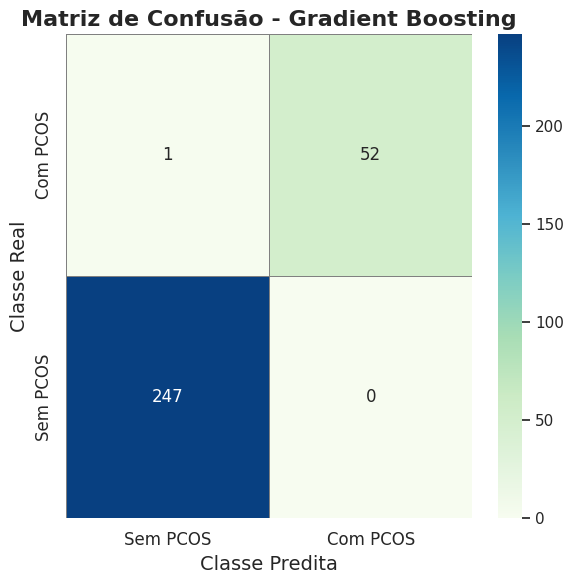

In [ ]:
classes = ['Sem PCOS', 'Com PCOS']

cm = confusion_matrix(y_test, best_model_gb.predict(X_test))

plt.figure(figsize=(6, 6))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="GnBu",
    cbar=True,
    linewidths=0.5,
    linecolor='gray',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Matriz de Confusão - Gradient Boosting", fontsize=16, fontweight="bold")
plt.xlabel("Classe Predita", fontsize=14)
plt.ylabel("Classe Real", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Salvando o Modelo de Predição

In [ ]:
import joblib

joblib.dump(best_model_gb, 'best_model_pcos.pkl')

['best_model_pcos.pkl']